In [1]:
#cell-1

!pip install seaborn xgboost shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

sns.set(style="whitegrid")

In [2]:
#cell-2

from google.colab import files

uploaded = files.upload()

Saving WQI Results on Dataset.csv to WQI Results on Dataset (1).csv


In [3]:
#cell-3

df = pd.read_csv("WQI Results on Dataset.csv")

df.head()

,WaterbodyName,Years,SampleDate,Alkalinity-total (as CaCO3),Ammonia-Total (as N),BOD - 5 days (Total),Chloride,Conductivity @25°C,Dissolved Oxygen,ortho-Phosphate (as P) - unspecified,...,CCME_Values,CCME_WQI,WAWQI_Values,WAWQI,Horton_values,Horton WQI,Brown_values,Brown WQI,SRDD_values,SRDD WQI
0,ABBEYTOWN_010,2023,Feb,314.0,0.033,1.2,27.3,711.0,52.50,0.019,...,64.105968,Moderate,68.121233,Good,117.590909,Unsuitable,72.726551,Good,38.469342,Poor
1,Allua,2007,Aug,14.0,0.033,1.2,10.0,71.0,61.85,0.019,...,76.753708,Fair,68.946463,Good,33.825455,Moderate,97.649888,Excellent,96.242574,Excellent
2,Allua,2007,Aug,17.0,0.033,1.2,11.5,79.0,61.80,0.019,...,77.222817,Fair,68.961140,Good,35.034545,Moderate,97.388310,Excellent,95.983952,Excellent
3,Allua,2007,Aug,18.0,0.033,1.2,11.3,78.0,62.40,0.019,...,76.953511,Fair,68.997174,Good,35.220000,Moderate,97.303327,Excellent,95.922072,Excellent
4,Allua,2007,Sep,19.0,0.033,1.2,10.5,76.0,66.05,0.019,...,76.867653,Fair,69.449725,Good,36.274545,Moderate,97.182033,Excellent,95.710180,Excellent


In [4]:
#Cell-4

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.info()

Shape: (21305, 24)

Columns:
 Index(['WaterbodyName', 'Years', 'SampleDate', 'Alkalinity-total (as CaCO3)',
       'Ammonia-Total (as N)', 'BOD - 5 days (Total)', 'Chloride',
       'Conductivity @25°C', 'Dissolved Oxygen',
       'ortho-Phosphate (as P) - unspecified', 'pH', 'Temperature',
       'Total Hardness (as CaCO3)', 'True Colour', 'CCME_Values', 'CCME_WQI',
       'WAWQI_Values', 'WAWQI', 'Horton_values', 'Horton WQI', 'Brown_values',
       'Brown WQI', 'SRDD_values', 'SRDD WQI'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21305 entries, 0 to 21304
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   WaterbodyName                         21305 non-null  object 
 1   Years                                 21305 non-null  int64  
 2   SampleDate                            21305 non-null  object 
 3   Alkalinity-total (as CaCO3)     

In [5]:
#cell-5

df.describe()

,Years,Alkalinity-total (as CaCO3),Ammonia-Total (as N),BOD - 5 days (Total),Chloride,Conductivity @25°C,Dissolved Oxygen,ortho-Phosphate (as P) - unspecified,pH,Temperature,Total Hardness (as CaCO3),True Colour,CCME_Values,WAWQI_Values,Horton_values,Brown_values,SRDD_values
count,21305.000000,21305.000000,21305.000000,21305.000000,21305.000000,21305.000000,21305.000000,21305.000000,21305.000000,21305.000000,21305.000000,21305.000000,21305.000000,21304.000000,21304.000000,21304.000000,21304.000000
mean,2014.748557,137.545424,0.061942,1.266754,20.698236,363.545963,56.941088,0.083837,7.512204,10.820245,155.746829,59.629913,72.848243,-48.062158,70.872698,87.355620,76.432964
std,4.427908,97.075950,0.401417,0.538787,21.909028,186.413055,26.910543,1.180554,0.596762,5.625520,101.241551,54.388955,8.320488,2107.621644,26.462914,7.986763,20.271961
min,2007.000000,0.000000,0.000000,0.000000,0.000000,33.000000,0.000000,-0.004000,4.700000,0.600000,0.000000,0.000000,34.331332,-124865.330270,16.927273,49.715918,-704.022584
25%,2011.000000,53.000000,0.033000,1.200000,15.600000,231.000000,48.900000,0.016000,7.150000,8.200000,68.000000,25.000000,66.856219,63.732440,50.727273,81.331649,65.939085
50%,2015.000000,127.000000,0.033000,1.200000,18.600000,356.000000,54.900000,0.019000,7.600000,10.700000,152.000000,45.000000,73.582805,68.193574,66.254545,88.690166,82.356606
75%,2018.000000,210.000000,0.033000,1.200000,22.000000,497.000000,63.750000,0.020000,8.000000,13.100000,231.000000,76.000000,78.516927,73.529680,89.756818,94.331862,90.657783
max,2023.000000,442.000000,40.000000,16.000000,1260.000000,4200.000000,198.000000,70.000000,9.800000,637.000000,642.000000,953.000000,100.000000,110.571361,530.872727,99.247424,98.884619


In [6]:
#Cell-6

missing = df.isnull().sum()
missing = missing[missing > 0]

print("Missing Values:\n", missing)

Missing Values:
 CCME_WQI         1
WAWQI_Values     1
WAWQI            1
Horton_values    1
Horton WQI       1
Brown_values     1
Brown WQI        1
SRDD_values      1
SRDD WQI         1
dtype: int64


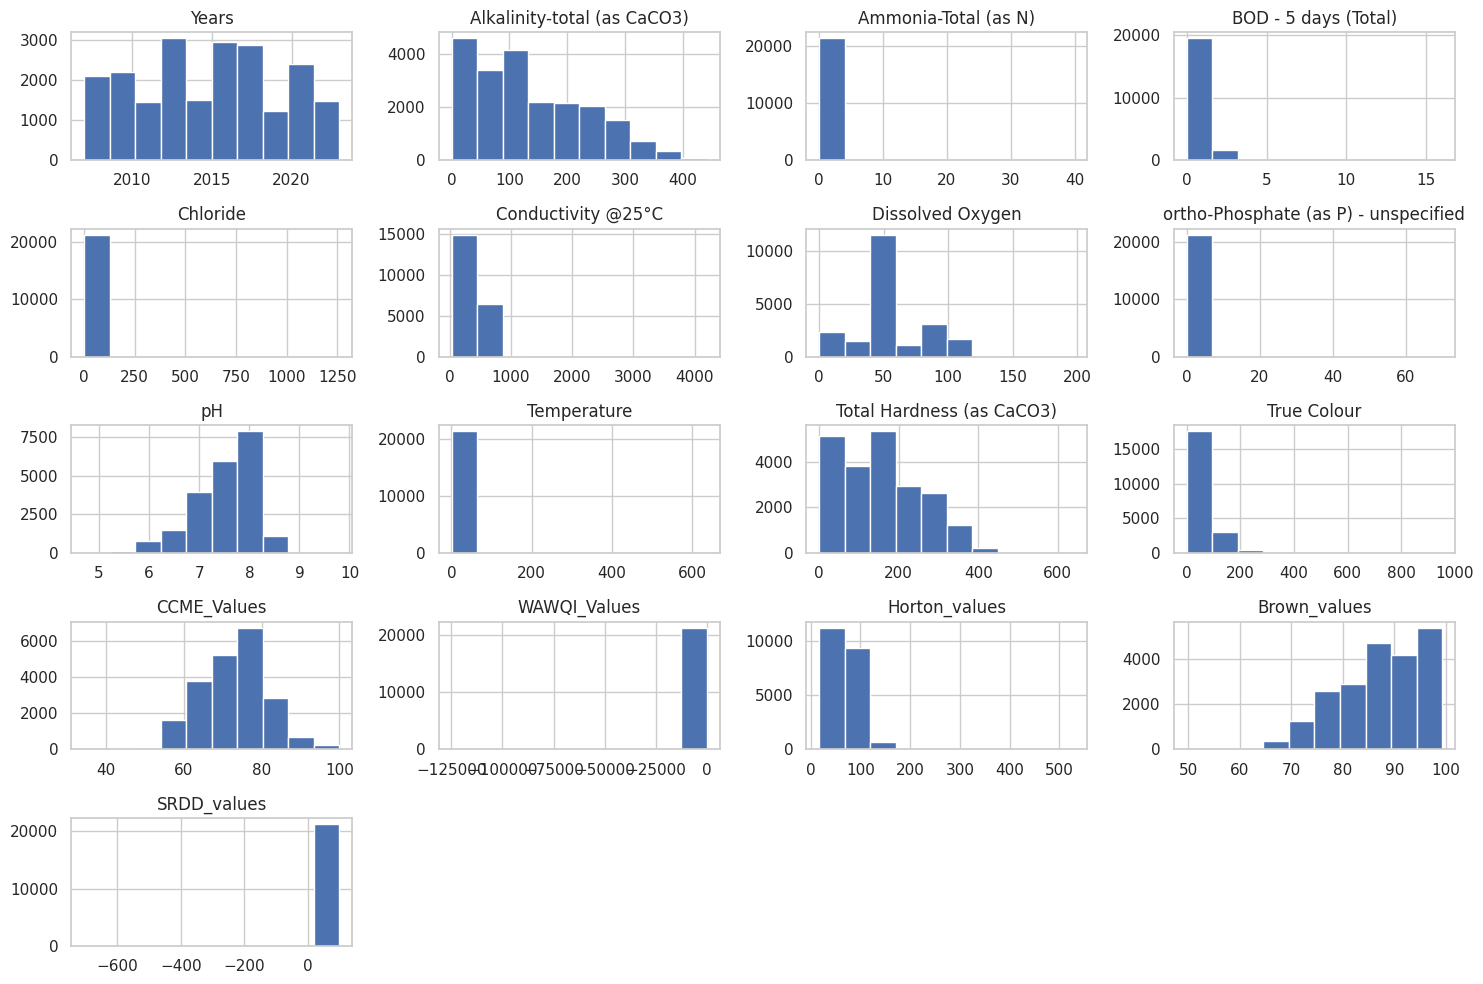

In [7]:
#Cell-7

df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

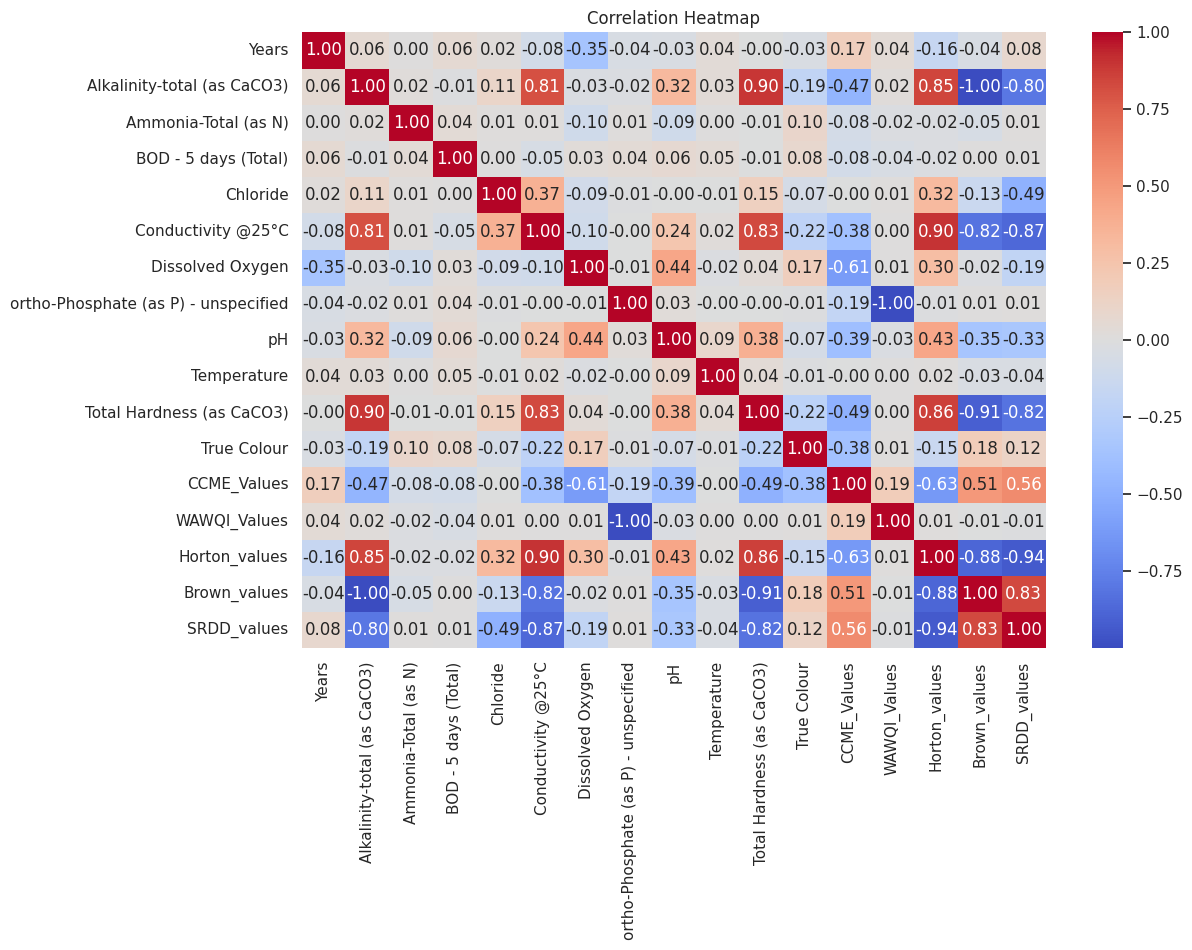

In [8]:
#Cell-8

plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
#Cell-9

min_val = df["CCME_Values"].min()
max_val = df["CCME_Values"].max()

print(f"Range of CCME: {min_val} to {max_val}")

Range of CCME: 34.331331713867385 to 100.0


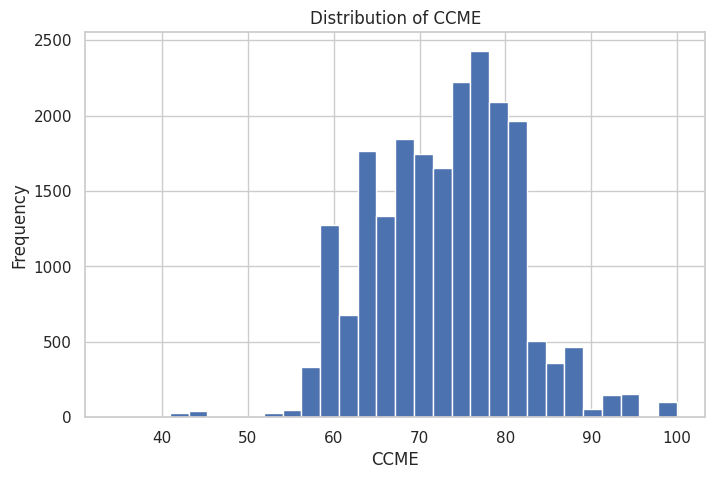

In [10]:
#Cell-10

target_col = "CCME_Values"

plt.figure(figsize=(8,5))
plt.hist(df[target_col], bins=30)
plt.title("Distribution of CCME")
plt.xlabel("CCME")
plt.ylabel("Frequency")
plt.show()

In [11]:
#Cell-11

drop_cols = ['id', 'station', 'date', 'CCME_WQI', 'WAWQI', 'WAWQI_Values', 'Horton_values', 'Horton WQI', 'Brown_values', 'Brown WQI', 'SRDD_values', 'SRDD WQI']


df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [12]:
#Cell-12

X = df.drop(columns=[target_col])
y = df[target_col]

In [13]:
#Cell-13

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (17044, 14)
Test Shape: (4261, 14)


In [14]:
#cell-14
# NEW CELL - Preprocessing + Pipeline (AFTER Cell-13)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Identify columns
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

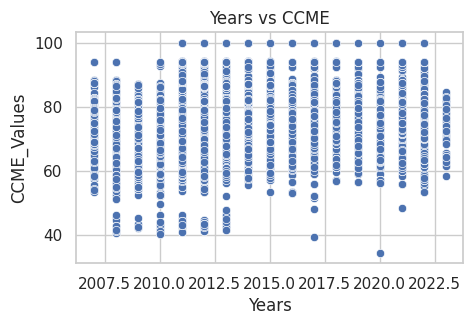

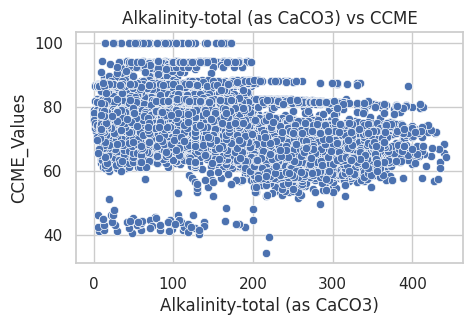

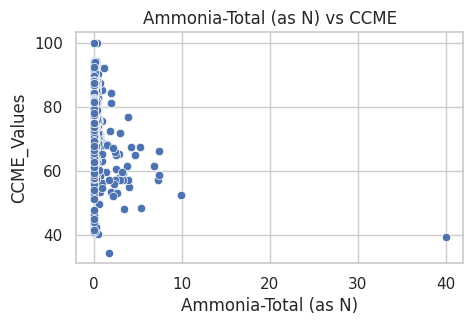

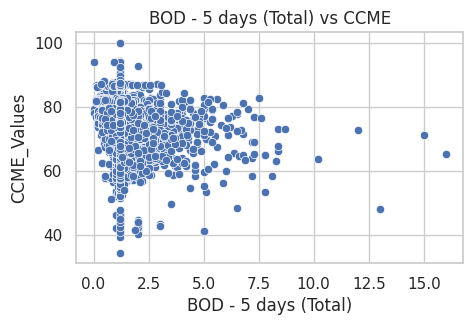

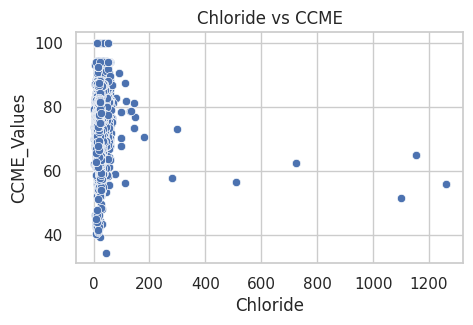

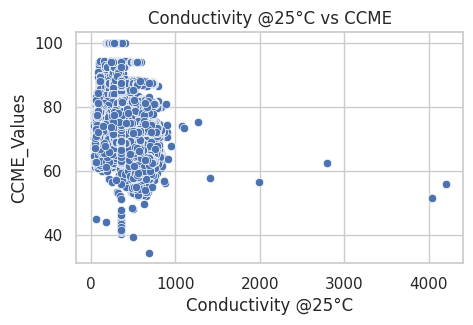

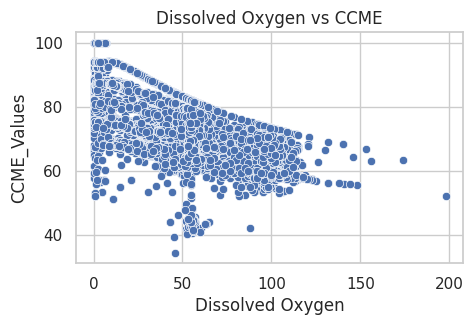

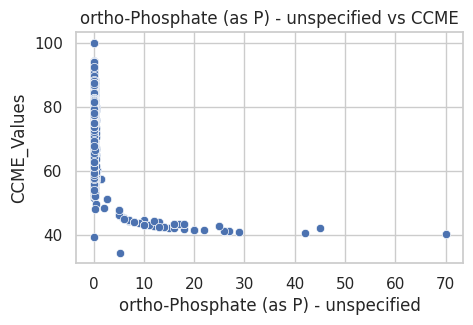

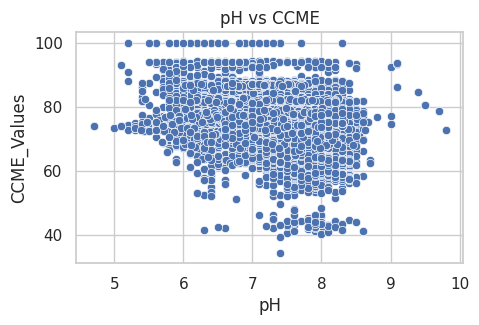

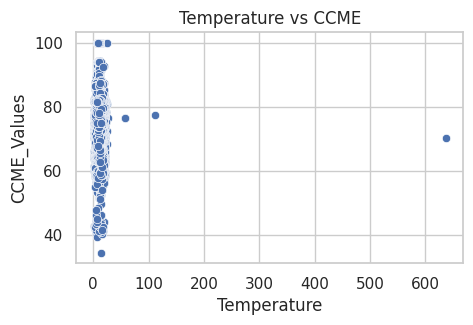

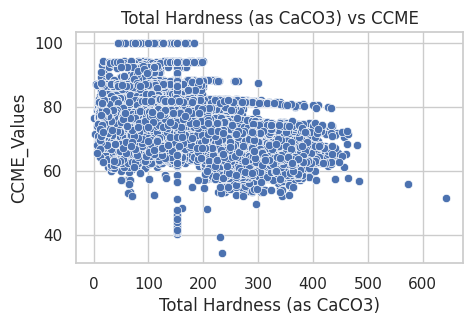

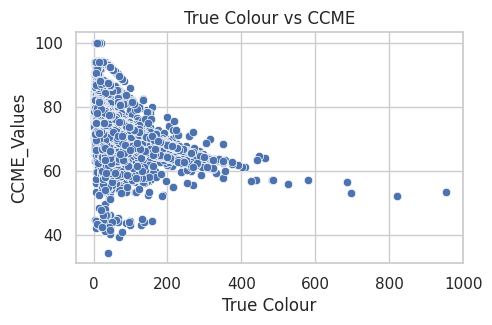

In [15]:
#Cell-15

for col in num_cols:
    if col != target_col:
        plt.figure(figsize=(5,3))
        sns.scatterplot(x=df[col], y=df[target_col])
        plt.title(f"{col} vs CCME")
        plt.show()

In [16]:
#Cell-18

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import shap

In [17]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

param_grid_lr = {
    'model__fit_intercept': [True, False],
    'model__positive': [True, False]
}

grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring='r2', n_jobs=-1)
grid_lr.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Years', 'Alkalinity-total (as CaCO3)', 'Ammonia-Total (as N)',
       'BOD - 5 days (Total)', 'Chloride', 'Conductivity @25°C',
       'Dissolved Oxygen', 'ortho-Phosphate (as P) - unspecified', 'pH',
       'Temp...
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                                         unknown_value=-1))]),
                                                                         Index(['WaterbodyName', 'SampleDate'], dtype='object'))])),
                                       ('model', LinearRegression())]),
             n_jobs=-1,
             param_grid={'model__fit_intercept': [True, False],
                         'model__positive': [True, False]},
             scoring='r2')

In [18]:
#Cell-20

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)


print("Tuned Linear Regression Results")
print("R2 Score :", r2_score(y_test, y_pred_lr))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE      :", mean_absolute_error(y_test, y_pred_lr))

Tuned Linear Regression Results
R2 Score : 0.8091484780105277
RMSE     : 3.6866505087912054
MAE      : 2.5551669198413176


In [19]:
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10],
    'model__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Years', 'Alkalinity-total (as CaCO3)', 'Ammonia-Total (as N)',
       'BOD - 5 days (Total)', 'Chloride', 'Conductivity @25°C',
       'Dissolved Oxygen', 'ortho-Phosphate (as P) - unspecified', 'pH',
       'Temp...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                                         unknown_value=-1))]),
                                                                         Index(['WaterbodyName', 'SampleDate'], dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [20]:
#Cell-22

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Random Forest Results")
print("R2 Score :", r2_score(y_test, y_pred_rf))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE      :", mean_absolute_error(y_test, y_pred_rf))

Random Forest Results
R2 Score : 0.9905641523738021
RMSE     : 0.8197371444122944
MAE      : 0.4711948136700077


In [21]:
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBRegressor(random_state=42))
])

param_grid_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 7],
    'model__learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Years', 'Alkalinity-total (as CaCO3)', 'Ammonia-Total (as N)',
       'BOD - 5 days (Total)', 'Chloride', 'Conductivity @25°C',
       'Dissolved Oxygen', 'ortho-Phosphate (as P) - unspecified', 'pH',
       'Temp...
                                                     max_cat_threshold=None,
                                                     max_cat_to_onehot=None,
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 7],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [22]:
#Cell-24

best_xgb = grid_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

print("XGBoost Results")
print("R2 Score :", r2_score(y_test, y_pred_xgb))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE      :", mean_absolute_error(y_test, y_pred_xgb))

XGBoost Results
R2 Score : 0.997803272625255
RMSE     : 0.3955234488564031
MAE      : 0.1607257796193903


In [23]:
#Cell-25

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": best_lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

for name, model in models.items():
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=kf,
        scoring='r2'
    )

    print(f"\n{name}")
    print("Fold Scores :", cv_scores)
    print("Mean R2     :", cv_scores.mean())


Linear Regression
Fold Scores : [0.82049969 0.80503944 0.81822178 0.81816889 0.83257081]
Mean R2     : 0.8189001220203581

Random Forest
Fold Scores : [0.98734032 0.9900511  0.98642578 0.98947952 0.98645205]
Mean R2     : 0.9879497552442066

XGBoost
Fold Scores : [0.99357685 0.99671169 0.99028071 0.99522785 0.99491845]
Mean R2     : 0.994143110717355


In [24]:
#Cell-26

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ]
})

results

,Model,R2,RMSE,MAE
0,Linear Regression,0.809148,3.686651,2.555167
1,Random Forest,0.990564,0.819737,0.471195
2,XGBoost,0.997803,0.395523,0.160726


In [25]:

feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

# Get transformed data
X_train_transformed = best_rf.named_steps['preprocessor'].transform(X_train)
X_test_transformed = best_rf.named_steps['preprocessor'].transform(X_test)

# Convert to DataFrame
X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

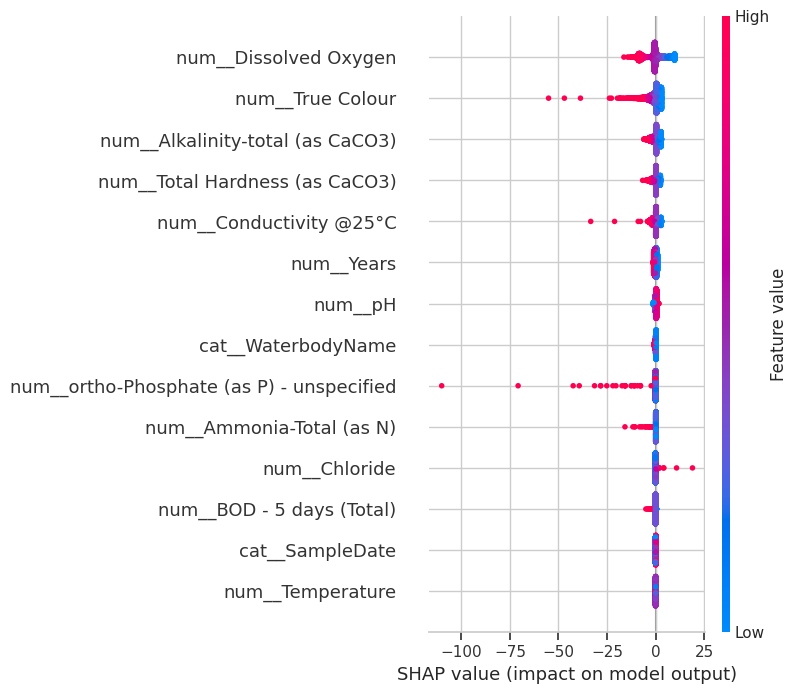

In [26]:
explainer_lr = shap.Explainer(best_lr.named_steps['model'], X_train_df)
shap_values_lr = explainer_lr(X_test_df)

shap.summary_plot(shap_values_lr, X_test_df)

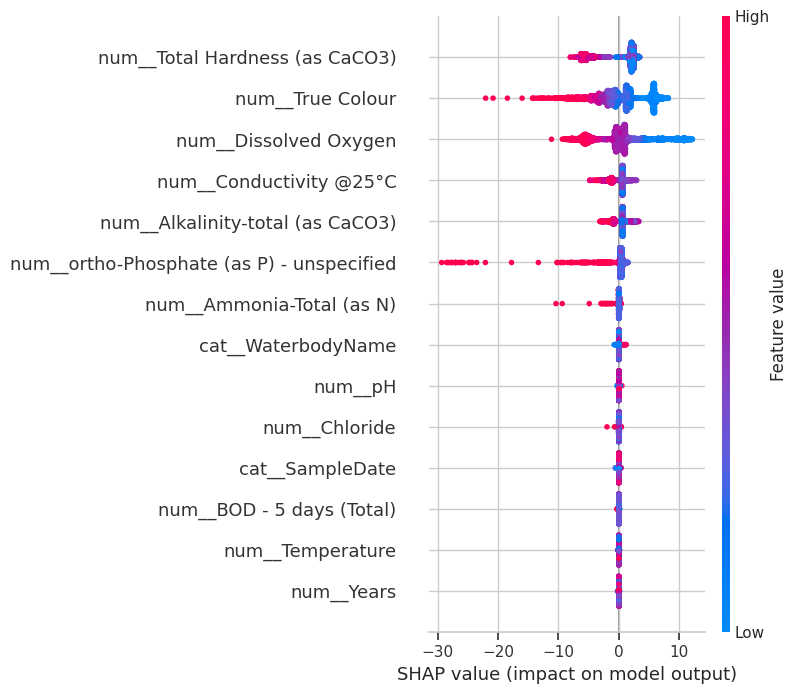

In [27]:
explainer = shap.TreeExplainer(best_rf.named_steps['model'])

shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df)

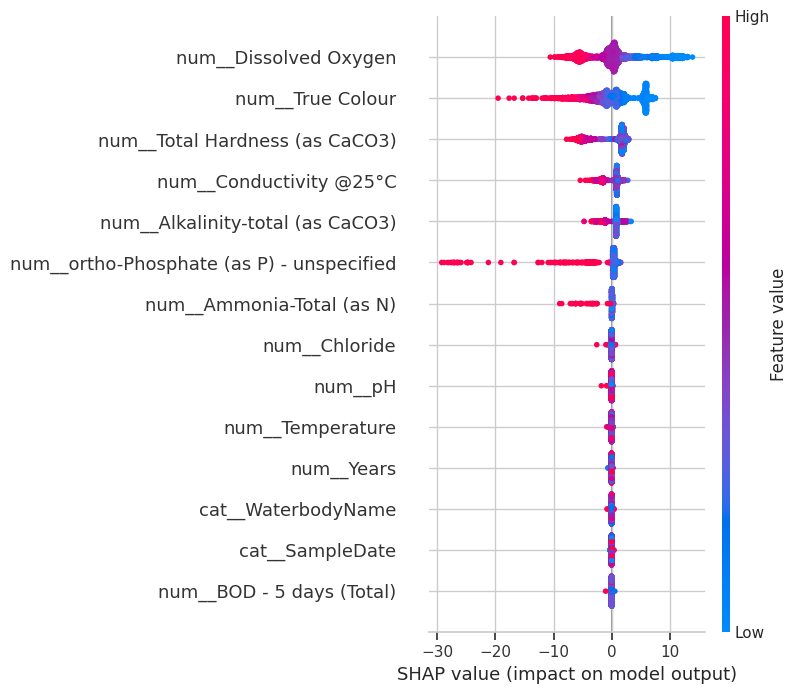

In [28]:
explainer_xgb = shap.TreeExplainer(best_xgb.named_steps['model'])

shap_values_xgb = explainer_xgb.shap_values(X_test_df)

shap.summary_plot(shap_values_xgb, X_test_df)

In [29]:
#Cell-30

n = X_test.shape[0]
p = X_test_df.shape[1]

def adjusted_r2(r2, n, p):
    return 1 - (1-r2)*(n-1)/(n-p-1)

for name, pred in zip(
    ["LR", "RF", "XGB"],
    [y_pred_lr, y_pred_rf, y_pred_xgb]
):
    r2 = r2_score(y_test, pred)
    print(name, "Adjusted R2:", adjusted_r2(r2, n, p))

LR Adjusted R2: 0.8085191983807932
RF Adjusted R2: 0.9905330402996696
XGB Adjusted R2: 0.9977960295298131


In [30]:
#Cell-31

import joblib

joblib.dump(best_lr, "linear_pipeline.pkl")
joblib.dump(best_rf, "rf_pipeline.pkl")
joblib.dump(best_xgb, "xgb_pipeline.pkl")

print("Pipelines saved successfully!")

Pipelines saved successfully!
